# Part 0: Setup

In [ ]:
#Install packages
using Pkg; Pkg.activate("."); Pkg.instantiate();

  Activating project at `~/Desktop/CPC_HGF_tutorial`
   Resolving package versions...
     Project No packages added to or removed from `~/Desktop/CPC_HGF_tutorial/Project.toml`
    Manifest No packages added to or removed from `~/Desktop/CPC_HGF_tutorial/Manifest.toml`


In [20]:
#Load packages
using HierarchicalGaussianFiltering #For the HGF
using ActionModels                  #For model-fitting and simulation
using StatsPlots                    #For plotting
using DataFrames, CSV, Downloads    #For loading data

# Part 1: Filtering binary outcomes
In this tutorial, we will fit HGF models to data.
This requires that the HGF is extended with a response model, so that it can generate behaviour.
For this part, we will use data from [this experiment](https://www.sciencedirect.com/science/article/pii/S1053811920310752).
Here, participants are presented with a binary observation, and have to predict the next observation.
To do this, they must learn the probability of the observations.
These probabilities change during the experiment, making it a classic reversal learning experiment.


In [21]:
#Read the data
observations = Int64.(CSV.read(Downloads.download("https://raw.githubusercontent.com/ComputationalPsychiatry/HierarchicalGaussianFiltering.jl/uHGF_real/docs/julia_files/tutorials/data/classic_binary_inputs.csv"), Tables.matrix)[:,1]);
actions = Int64.(CSV.read(Downloads.download("https://raw.githubusercontent.com/ComputationalPsychiatry/HierarchicalGaussianFiltering.jl/uHGF_real/docs/julia_files/tutorials/data/classic_binary_actions.csv"), Tables.matrix)[:,1]);

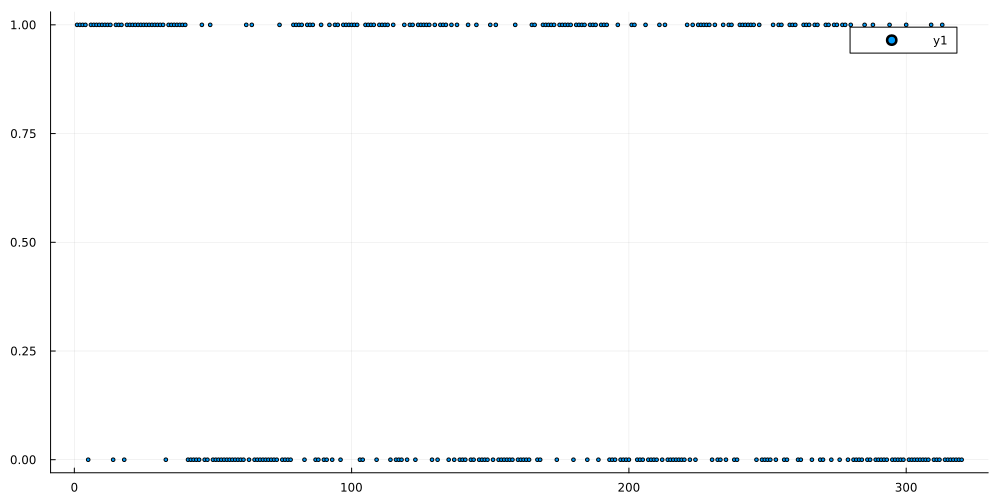

In [22]:
#Plot the observations
plot(observations, markersize = 2, seriestype = :scatter, size = (1000, 500))

We will first here use the classic Binary 3level HGF.
Below is a depction of its generative model.

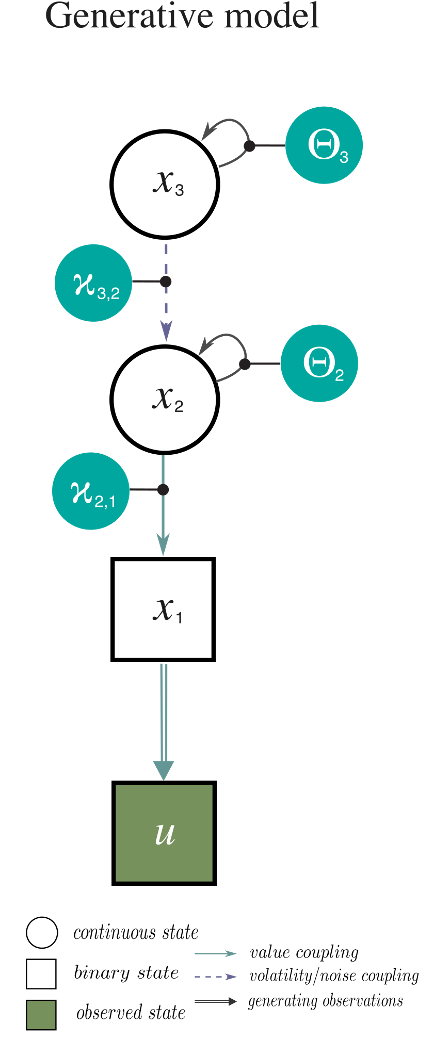

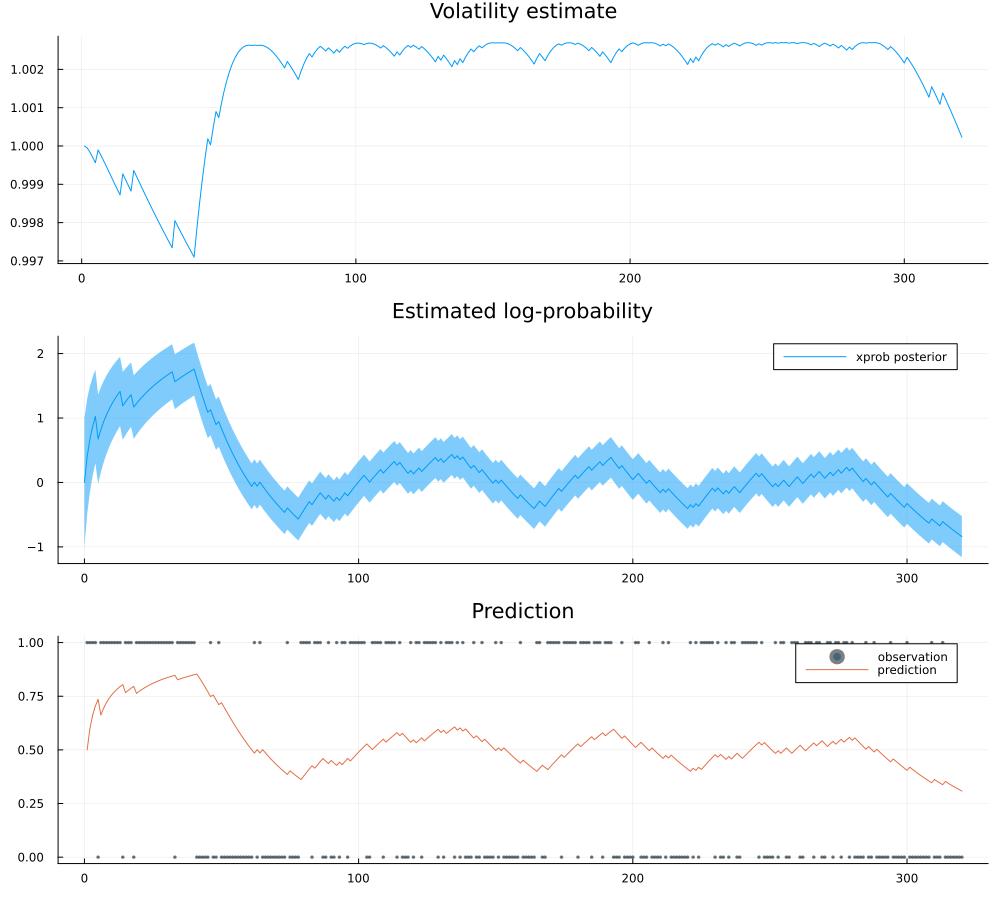

In [23]:
#Create HGF
hgf = premade_hgf("binary_3level")

#Set parameters
parameters = Dict(
  ("xprob", "volatility") => -7,                   #ω₂
  ("xprob", "drift") => 0,                         #ρ₂
  ("xprob", "autoconnection_strength") => 1,       #λ₂
  ("xprob", "initial_mean") => 0,                  #μ₀
  ("xprob", "initial_precision") => 1,             #π₀

  ("xvol", "volatility") => -7,                    #ω₃
  ("xvol", "drift") => 0,                          #ρ₃
  ("xvol", "autoconnection_strength") => 1,        #λ₃
  ("xvol", "initial_mean") => 1.0,                 #μ₀
  ("xvol", "initial_precision") => 1,              #π₀

  ("xprob", "xvol", "coupling_strength") => 1.,    #κ₃₂
  ("xbin", "xprob", "coupling_strength") => 1.     #κ₂₁
)

set_parameters!(hgf, parameters)



#Give observations to the HGF
reset!(hgf)
multiple_inputs!(hgf, observations)



#Plot the inferred state
plt_xbin = plot(hgf, "u", markersize = 1, alpha = 0.5, label = "observation")
plot!(hgf, "xbin", label = "prediction")
title!("Prediction")

#Plot the inferred log-probability
plt_xprob = plot(hgf, "xprob", title = "Estimated log-probability")

#Plot the inferred volatility
plt_vol = plot(hgf.all_nodes["xvol"].history.posterior_mean, title = "Volatility estimate")
#plt_vol = plot(hgf, "xvol", title = "Volatility estimate")
title!("Volatility estimate", legend = false)

#Plot together
plot(
  plt_vol,
  plt_xprob,
  plt_xbin,
  layout = (3,1),
  size = (1000,900)
)


## Exercise 1
Change the parameters of the binary 3level HGF to see how they affect belief updates.
In the following code block is an example of creating a custom binary HGF.
Try and create your own (for example adding a drift parent), and see how belief updates change.

In [24]:
#List of nodes
nodes = [
    BinaryInput(name = "u"),
    BinaryState(name = "xbin"),
    ContinuousState(name = "xprob"),
    ContinuousState(name = "xvol"),
    ]

#List of child-parent relations
edges = Dict(
    ("u", "xbin") => ObservationCoupling(),
    ("xbin", "xprob") => ProbabilityCoupling(),
    ("xprob", "xvol") => VolatilityCoupling(),
)

#Initialize the HGF
hgf_binary_3level = init_hgf(
    nodes = nodes,
    edges = edges,
)

┌ Warning: No update order specified. Using the order in which nodes were inputted
└ @ HierarchicalGaussianFiltering /Users/peter/.julia/packages/HierarchicalGaussianFiltering/NMcA2/src/create_hgf/init_hgf.jl:78


-- HGF struct --
Number of input nodes: 1
(0 continuous, 1 binary and 0 categorical)
Number of state nodes: 3
(2 continuous, 1 binary, and 0 categorical)


# Part 2: Simulating actions
In this part, we will now add a response model so that the model can generate behaviour.
This means we create an "action model" - i.e., a model of the full action-generation process.
We will use a standard Unit Square Sigmoid transform model here. This response model has an action noise parameter.
Note that we are now relying on the ActionModels package, and that the syntax is therefore different (we use a NamedTuple instead of a Dict to specify parameters).

In [25]:
#Create HGF
hgf = premade_hgf("binary_3level")

#Create action model
action_model = ActionModel(HGFSigmoid(; HGF = hgf))

-- ActionModel --
Action model function: hgf_sigmoid
Number of parameters: 1
Number of states: 0
Number of observations: 1
Number of actions: 1
submodel type: HierarchicalGaussianFiltering.HGF


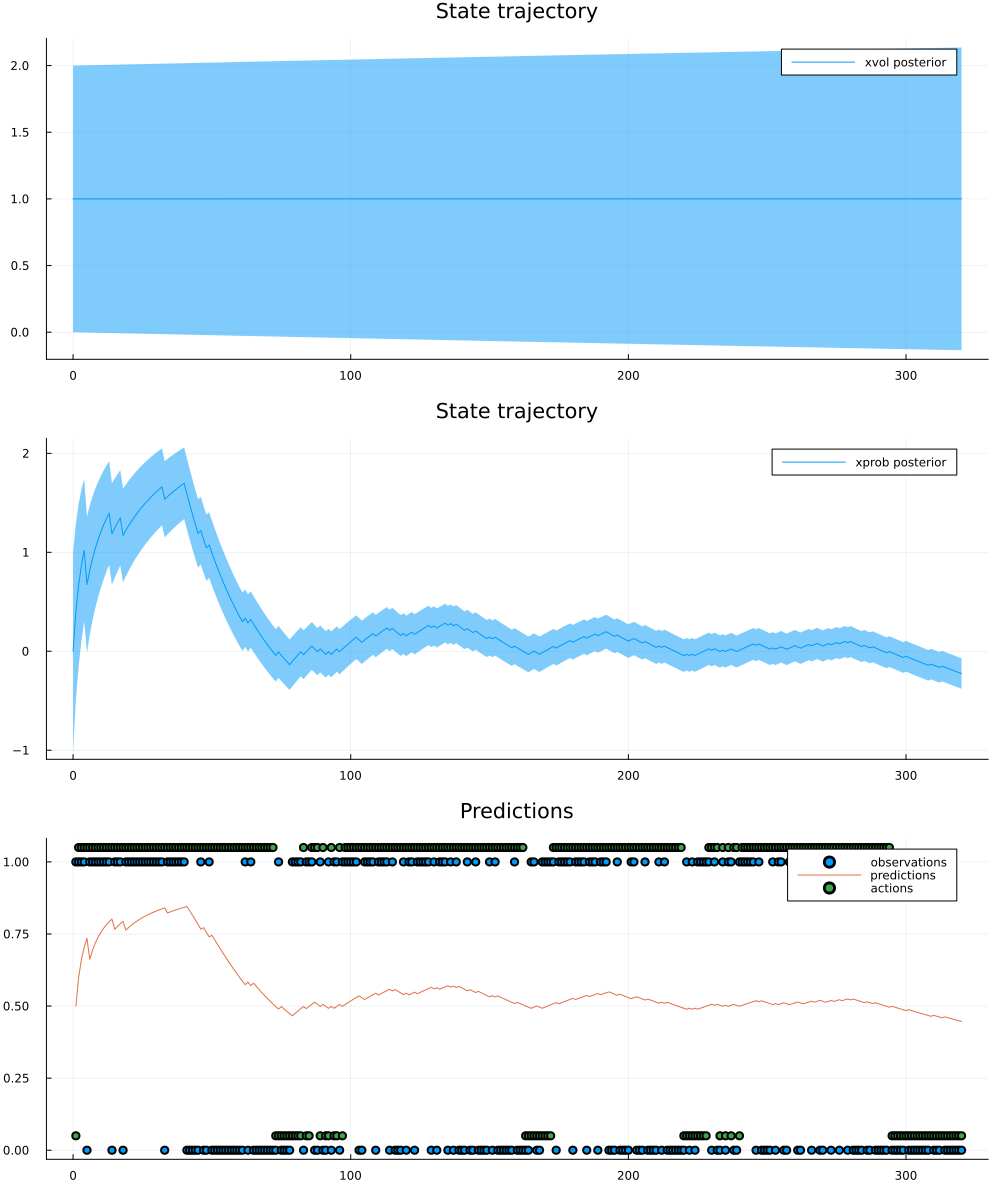

In [12]:
#Create agent
agent = init_agent(action_model)

parameters = (
  action_noise = 0.01,                    #β

  xprob_volatility = -10,                 #ω₂
  xprob_drift = 0,                       #ρ₂
  xprob_autoconnection_strength = 1,     #λ₂
  xprob_initial_mean = 0,                #μ₀
  xprob_initial_precision = 1,           #π₀

  xvol_volatility = -7,                  #ω₃
  xvol_drift = 0,                        #ρ₃
  xvol_autoconnection_strength = 1,      #λ₃
  xvol_initial_mean = 1.0,               #μ₀
  xvol_initial_precision = 1,            #π₀

  xprob_xvol_coupling_strength = 1.,    #κ₃₂
  xbin_xprob_coupling_strength = 1.     #κ₂₁
)

set_parameters!(agent, parameters)

reset!(agent)

#Simulate behaviour
simulated_actions = simulate!(agent, observations)



# Plot the trajectory of the agent
plt_prediction = plot(agent, "u", label = "observations", legend = :topright)
plot!(agent, "xbin", label = "predictions")
plot!(simulated_actions .+ 0.05, title = "Predictions", label = "actions", seriestype = :scatter)

plt_prob = plot(agent, ("xprob", "posterior"))

plt_volatility = plot(agent, ("xvol", "posterior"))

plot(
  plt_volatility,
  plt_prob,
  plt_prediction,
  layout = (3,1),
  size = (1000, 1200)
)

We can compare this to the behaviour of the real participant:

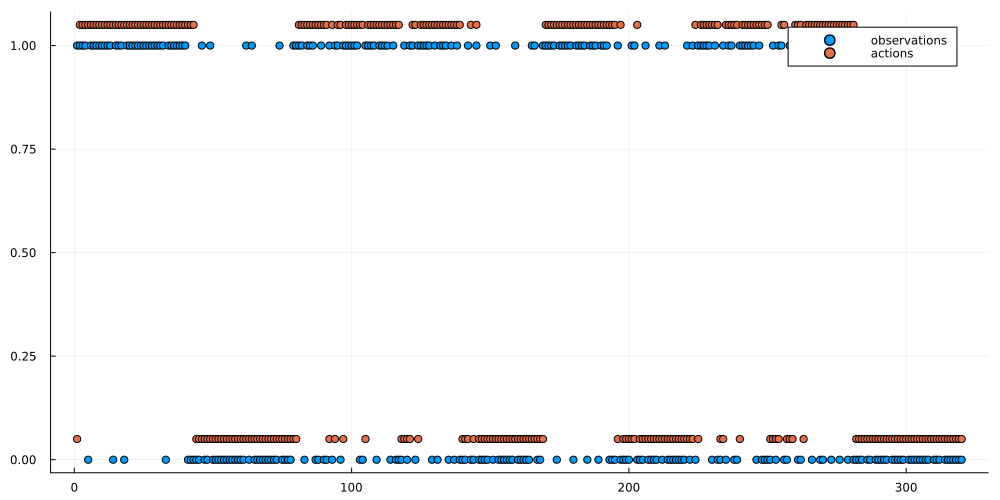

In [26]:
plot(observations, label = "observations", seriestype = :scatter, size = (1000, 500))
plot!(actions .+ 0.05, label = "actions", seriestype = :scatter)

## Exercise 2
Vary the parameters above, change the HGF, and see how it changes the behaviour.
See if you can find parameter values that make the model produce data that is similar to the real data.

# Part 3 (Optional): Custom response models
We can also create custom response models.
In the following, we show how to create response models with ActionModels.jl.
Essentially, the user specifies a function that takes observations and returns a probability distribution over actions.

In [27]:
#Create HGF
hgf = premade_hgf("binary_2level")

#Define model function
function hgf_softmax(attributes::ModelAttributes, observation::Int64)

    ## Unpack attributes ##
    #Load HGF
    hgf = attributes.submodel

    #Load parameters
    β⁻¹ = 1 / load_parameters(attributes).action_noise

    ## Update the HGF ##
    update_hgf!(hgf, observation)


    ## Response model ##
    #Get HGF prediction
    μ̂ₜ = get_states(hgf, ("xbin", "prediction_mean"))

    #Softmax transformation
    Pₐ = logistic(β⁻¹ * (μ̂ₜ - (1 - μ̂ₜ)))

    #Return the action distribution
    return Bernoulli(Pₐ)
end

#Create action model
action_model = ActionModel(
    hgf_softmax,
    parameters = parameters = (action_noise = Parameter(0.1)),
    observations = (observation = Observation(discrete = true)),
    actions = (report = Action(Bernoulli)),
    submodel = hgf,
)

┌ Warning: A single parameter was passed, and is given the name :parameter. Use (; parameter_name = parameter) to specify the name of the parameter.
└ @ ActionModels /Users/peter/.julia/packages/ActionModels/wzKxd/src/defining_models/structs.jl:406
┌ Warning: A single action was passed, and is given the name :action. Use (; action_name = action) to specify the name of the action.
└ @ ActionModels /Users/peter/.julia/packages/ActionModels/wzKxd/src/defining_models/structs.jl:418
┌ Warning: A single observation was passed, and is given the name :observation. Use (; observation_name = observation) to specify the name of the observation.
└ @ ActionModels /Users/peter/.julia/packages/ActionModels/wzKxd/src/defining_models/structs.jl:424


-- ActionModel --
Action model function: hgf_softmax
Number of parameters: 1
Number of states: 0
Number of observations: 1
Number of actions: 1
submodel type: HierarchicalGaussianFiltering.HGF


## Exercise 3
Try and use the action model above instead of the sigmoid model.
See if you see a difference in the behaviour (they are similar!)
Try out making changes to the response model, or using a different type of HGF with it.
If you want to be very experimental with the response model design, you can ask Peter for further details, or look at the ActionModels documentation:
https://computationalpsychiatry.github.io/ActionModels.jl/stable/

# Part 4: Fitting to data
In the above, we have done a kind "qualitative model fitting" where we find parameter values that generate data similar to the real data.
Now we will do proper model fitting, using MCMC.
ActionModels makes this easy, by relying on the Turing.jl library as backend.

We need to set priors, and then we can create a full probabilistic model that can be fit to the data.

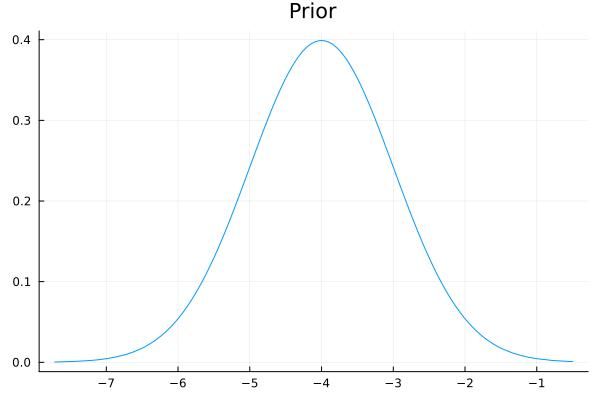

In [28]:
#Plot the priors to make sure they look reasonable, given your experience with the HGF
plot(truncated(Normal(-4, 1), upper = -0.5), legend = false, title = "Prior")

In [ ]:
#Create default 2-level binary HGF
action_model = ActionModel(HGFSoftmax(; HGF = "binary_2level"))

#Set priors
prior = (
  xprob_volatility = truncated(Normal(-4, 1), upper = -0.5),
  action_noise = truncated(Normal(), lower = 0),
)

#Create full model
full_model = create_model(
  action_model,
  prior,
  observations,
  actions,

  #This will ensure that the sampler handles invalid parameter values
  check_parameter_rejections = true,
)

-- ModelFit object --
Action model: hgf_softmax
Custom population model
2 estimated action model parameters, 1 sessions
Posterior not sampled
Prior not sampled


We can now fit the model with the sample_posterior! command.
We can specify the number of chains and samples, and we can run chains in parallel.

In [35]:
#Use MCMC to fit the model to the data
chns = sample_posterior!(full_model, MCMCThreads(), n_chains = 2, n_samples = 300, resample = true)

┌ Warning: Only a single thread available: MCMC chains are not sampled in parallel
└ @ AbstractMCMC /Users/peter/.julia/packages/AbstractMCMC/NK6XN/src/sample.jl:544
Sampling (1 thread)   0%|                               |  ETA: N/A
┌ Info: Found initial step size
│   ϵ = 0.8
└ @ Turing.Inference /Users/peter/.julia/packages/Turing/IXycm/src/mcmc/hmc.jl:207
Sampling (1 thread)   0%|▏                              |  ETA: 0:14:07
Sampling (1 thread)   1%|▎                              |  ETA: 0:07:03
Sampling (1 thread)   2%|▌                              |  ETA: 0:04:42
Sampling (1 thread)   2%|▋                              |  ETA: 0:03:33
Sampling (1 thread)   2%|▊                              |  ETA: 0:02:52
Sampling (1 thread)   3%|▉                              |  ETA: 0:02:25
Sampling (1 thread)   4%|█▏                             |  ETA: 0:02:04
Sampling (1 thread)   4%|█▎                             |  ETA: 0:01:49
Sampling (1 thread)   4%|█▍                             |  ETA:

Chains MCMC chain (300×14×2 Array{Float64, 3}):

Iterations        = 151:1:450
Number of chains  = 2
Samples per chain = 300
Wall duration     = 11.47 seconds
Compute duration  = 10.45 seconds
parameters        = xprob_volatility.session[1], action_noise.session[1]
internals         = lp, n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size

Summary Statistics
                   parameters      mean       std      mcse   ess_bulk   ess_t ⋯
                       Symbol   Float64   Float64   Float64    Float64    Floa ⋯

  xprob_volatility.session[1]   -1.1845    0.3551    0.0207   256.3811   257.8 ⋯
      action_noise.session[1]    0.5863    0.0870    0.0040   504.3345   323.3 ⋯
                                                               3 columns omitted

Quantiles
                   parameters      2.5%     25.0%     50.0%     75.0%     97.5 ⋯
            

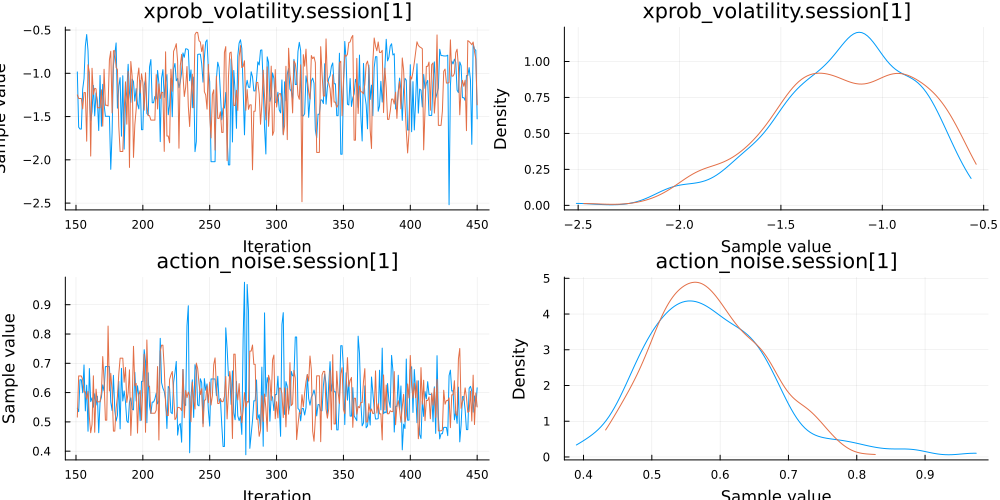

In [36]:
#Visualise the chains
plot(chns)

In [37]:
session_parameters = get_session_parameters!(full_model)
parameter_df = summarize(session_parameters, median)

Row,session,action_noise,xprob_volatility
,String,Float64,Float64
1,single_session,0.577222,-1.16036


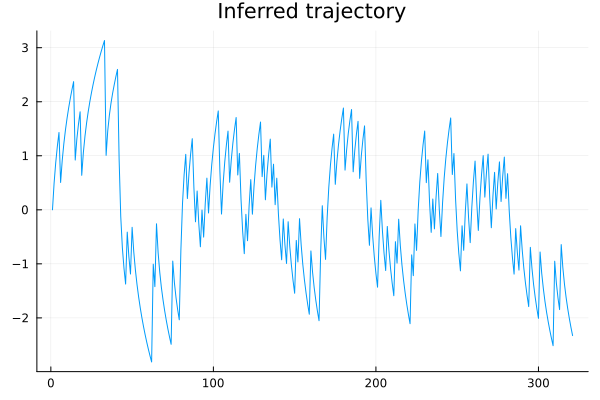

In [38]:
#Get the trajectory of states over time
target_state = :xprob_prediction_mean

state_trajectories = get_state_trajectories!(full_model, target_state)
#Get the median estimates
state_df = summarize(state_trajectories, median)

plot(state_df[:, target_state], label = "", title = "Inferred trajectory")

## Exercise 4
We have now inferred parmaeter values from the data - congratulations!
Change the priors and see how it affects inference.
Estimate parameters other than the volatility and action noise.
Change the HGF model and see if you can find interesting effects.
Change the response model and see what happens.

# Part 4 (Optional): The Predictive Inference Task
In this optional section, we will fit the HGF to data from the predictive inference task (also known as the Jumping Gaussian Estimation Task).
We will use data from [this experiment](https://www.nature.com/articles/s41467-023-39823-5).
It is recommended to do the final part of the first assignment before doing this.

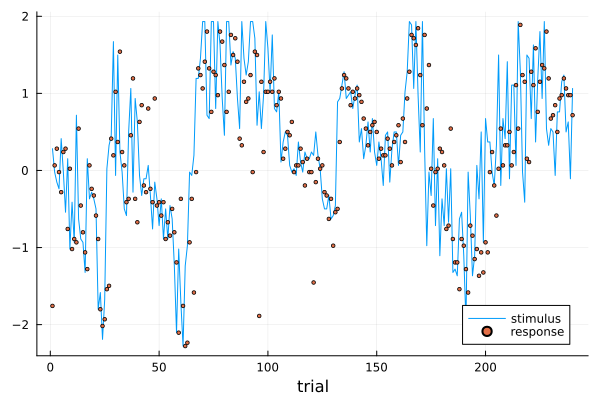

In [39]:
#Read into a DataFrame
data = CSV.read(Downloads.download(
  "https://raw.githubusercontent.com/ComputationalPsychiatry/HierarchicalGaussianFiltering.jl/main/docs/julia_files/tutorials/data/classic_cannonball_data.csv"
  ), DataFrame, missingstring = ["NaN", ""])

#Remove ID's with missing responses
data = combine(
    groupby(data, [:ID, :session]),
    subdata -> any(ismissing, Matrix(subdata[!, [:response]])) ? DataFrame() : subdata,
)
disallowmissing!(data, [:response])
#Remove participant 22 from the data, where collection has
data = filter(row -> !(row[:ID] == 22), data)

#z-score the outcome and response
z_μ = mean(vcat(data.outcome, data.response))
z_σ = std(vcat(data.outcome, data.response))
data.outcome_z = (data.outcome .- z_μ) ./ z_σ
data.response_z = (data.response .- z_μ) ./ z_σ

#Filter the data for the first session for the first participant
data = filter(:ID => ==(20), data)
data = filter(:session => ==(1), data)

#Extract data
observations = data.outcome_z
actions = data.response_z

plot(observations, markersize = 2, xlabel = "trial", label = "stimulus")
plot!(actions, seriestype = :scatter, markersize = 2, xlabel = "trial", label = "response")


In the following is a standard model that may be used for this experiment.
The HGF has one observation node u, which has a value parent x, and a noise parent xnoise. Finally, x has a volatility parent xvol.

In [40]:
## HGF model ##
#Define nodes
nodes = [
    ContinuousInput(name = "u"),
    ContinuousState(name = "x"),
    ContinuousState(name = "xnoise"),
    ContinuousState(name = "xvol"),
]

#Define edges
edges = Dict(("u", "x") => ObservationCoupling(), ("u", "xnoise") => NoiseCoupling(), ("x", "xvol") => VolatilityCoupling())

#Initialize HGF
hgf = init_hgf(nodes = nodes, edges = edges, save_history = false)

#Define parameter values
parameters = Dict(
    ("x", "initial_mean") => 0,                   # agnostic initial mean
    ("x", "initial_precision") => 0.01,           # low initial certainty
    ("xnoise", "initial_mean") => log((5) .^ 2), # low initial noise
    ("xnoise", "initial_precision") => 0.33,     # low initial certainty
)

#Set parameter values to the hgf
set_parameters!(hgf, parameters)





## Action model ##
#Action model function
function hgf_gaussian_response(attributes::ModelAttributes, input::Float64)

    ### Load attributes ###
    #Load parameters
    Θ = load_parameters(attributes)

    #Load the parameters for the action noise
    σ = Θ.action_noise                 # baseline response noise
    σ_precision = Θ.noise_influence_precision    # response noise influence from precision

    #Ready the HGF
    hgf = attributes.submodel

    ### Response model ###
    #Load prediction mean and prediction for the observation
    μ̂ᵤ, π̂ᵤ = get_prediction(hgf, "u")

    #On first trial, cheat by using the input as the prediction mean
    #This is to avoid the first trial having huge effect on the aciton noise
    if ismissing(μ̂ᵤ)
        μ̂ᵤ = input
    end

    #The noise in the response is baseline noise plus a weighted prediction precision
    σᵣ = exp(σ + σ_precision * log(π̂ᵤ))

    #The prediction report is drawn from a Gaussian distribution
    Pᵣ = Normal(μ̂ᵤ, σᵣ)

    ### HGF Update ###
    #Give the HGF the input
    update_hgf!(hgf, input)

    #Return both prediction and confidence actions
    return Pᵣ
end

#Define parameters
parameters = (
    #Parameters for the action noise
    action_noise = Parameter(0.1),
    noise_influence_precision = Parameter(0),
)

#Create action model
action_model = ActionModel(
    hgf_gaussian_response,
    parameters = parameters,
    observations = (; observation = Observation()),
    actions = (; prediction = Action(Normal)),
    submodel = hgf,
)

┌ Warning: No update order specified. Using the order in which nodes were inputted
└ @ HierarchicalGaussianFiltering /Users/peter/.julia/packages/HierarchicalGaussianFiltering/NMcA2/src/create_hgf/init_hgf.jl:78


-- ActionModel --
Action model function: hgf_gaussian_response
Number of parameters: 2
Number of states: 0
Number of observations: 1
Number of actions: 1
submodel type: HierarchicalGaussianFiltering.HGF


First we can simulate behaviour

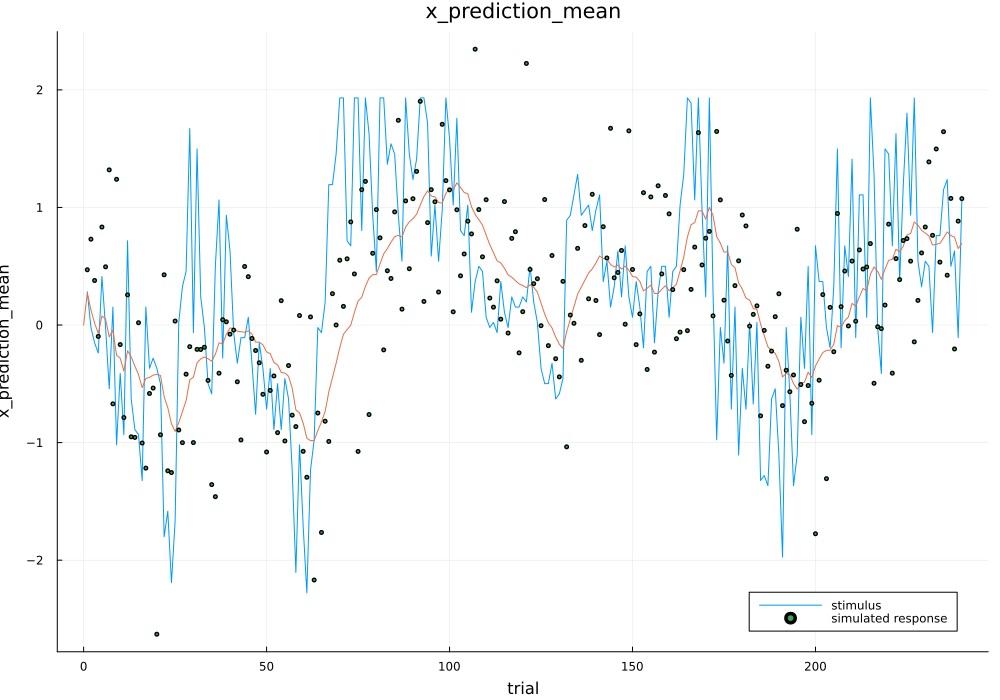

In [41]:
#Initialise agent
agent = init_agent(action_model, save_history = true)

parameters = (
  action_noise = -0.5,
  noise_influence_precision = 0.0,
  x_volatility = -5,
  xnoise_volatility = -5,
  xvol_volatility = -5,
)

set_parameters!(agent, parameters)
reset!(agent)


#Simulate behaviour
simulated_actions = simulate!(agent, observations)


plt_obs = plot(observations, markersize = 2, xlabel = "trial", label = "stimulus", size = (1000, 700))
plot!(agent, :x_prediction_mean)
plot!(simulated_actions, seriestype = :scatter, markersize = 2, xlabel = "trial", label = "simulated response")


### You can also plot the other belief states ###

#plt_precision = plot(agent, :x_prediction_precision)

#plt_noise = plot(agent, :xnoise_posterior_mean)

#plt_vol = plot(agent, :xvol_posterior_mean)

#plot(
#  plt_obs,
#  plt_precision,
#  plt_noise,
#  plt_vol,
#  layout = (4,1),
#  size = (1000,1500)
#)

## Exercise 5
Experiment with different parameters, the HGF structure, and the response model. See if you can find settings that make simulated behaviour similar to the real behaviour.

In [42]:
## Priors ##
prior = (
    #HGF parameters
    x_volatility = Normal(2, 1),
    xnoise_volatility = truncated(Normal(-4, 0.5), upper = -1),
    xvol_volatility = truncated(Normal(-4, 0.5), upper = -1),

    #Parameters for the action noise
    action_noise = Normal(0, 0.3),
    noise_influence_precision = Normal(0, 0.3),
)


## Full model ##
full_model = create_model(
    action_model,
    prior,
    observations,
    actions,
    check_parameter_rejections = true
)

-- ModelFit object --
Action model: hgf_gaussian_response
Custom population model
5 estimated action model parameters, 1 sessions
Posterior not sampled
Prior not sampled


In [43]:
chns = sample_posterior!(full_model, MCMCThreads(), n_chains = 2, n_samples = 500, resample = true)

┌ Warning: Only a single thread available: MCMC chains are not sampled in parallel
└ @ AbstractMCMC /Users/peter/.julia/packages/AbstractMCMC/NK6XN/src/sample.jl:544
Sampling (1 thread)   0%|                               |  ETA: N/A
┌ Info: Found initial step size
│   ϵ = 0.2
└ @ Turing.Inference /Users/peter/.julia/packages/Turing/IXycm/src/mcmc/hmc.jl:207
Sampling (1 thread)   0%|▏                              |  ETA: 0:15:22
Sampling (1 thread)   1%|▎                              |  ETA: 0:07:50
Sampling (1 thread)   2%|▌                              |  ETA: 0:05:23
Sampling (1 thread)   2%|▋                              |  ETA: 0:04:08
Sampling (1 thread)   2%|▊                              |  ETA: 0:03:20
Sampling (1 thread)   3%|▉                              |  ETA: 0:02:51
Sampling (1 thread)   4%|█▏                             |  ETA: 0:02:31
Sampling (1 thread)   4%|█▎                             |  ETA: 0:02:17
Sampling (1 thread)   4%|█▍                             |  ETA:

Chains MCMC chain (500×17×2 Array{Float64, 3}):

Iterations        = 251:1:750
Number of chains  = 2
Samples per chain = 500
Wall duration     = 23.86 seconds
Compute duration  = 23.31 seconds
parameters        = x_volatility.session[1], xnoise_volatility.session[1], xvol_volatility.session[1], action_noise.session[1], noise_influence_precision.session[1]
internals         = lp, n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size

Summary Statistics
                            parameters      mean       std      mcse   ess_bul ⋯
                                Symbol   Float64   Float64   Float64    Float6 ⋯

               x_volatility.session[1]    2.5871    0.8274    0.0315   690.643 ⋯
          xnoise_volatility.session[1]   -4.1951    0.4807    0.0168   827.409 ⋯
            xvol_volatility.session[1]   -4.9789    0.3570    0.0118   913.107 ⋯
            

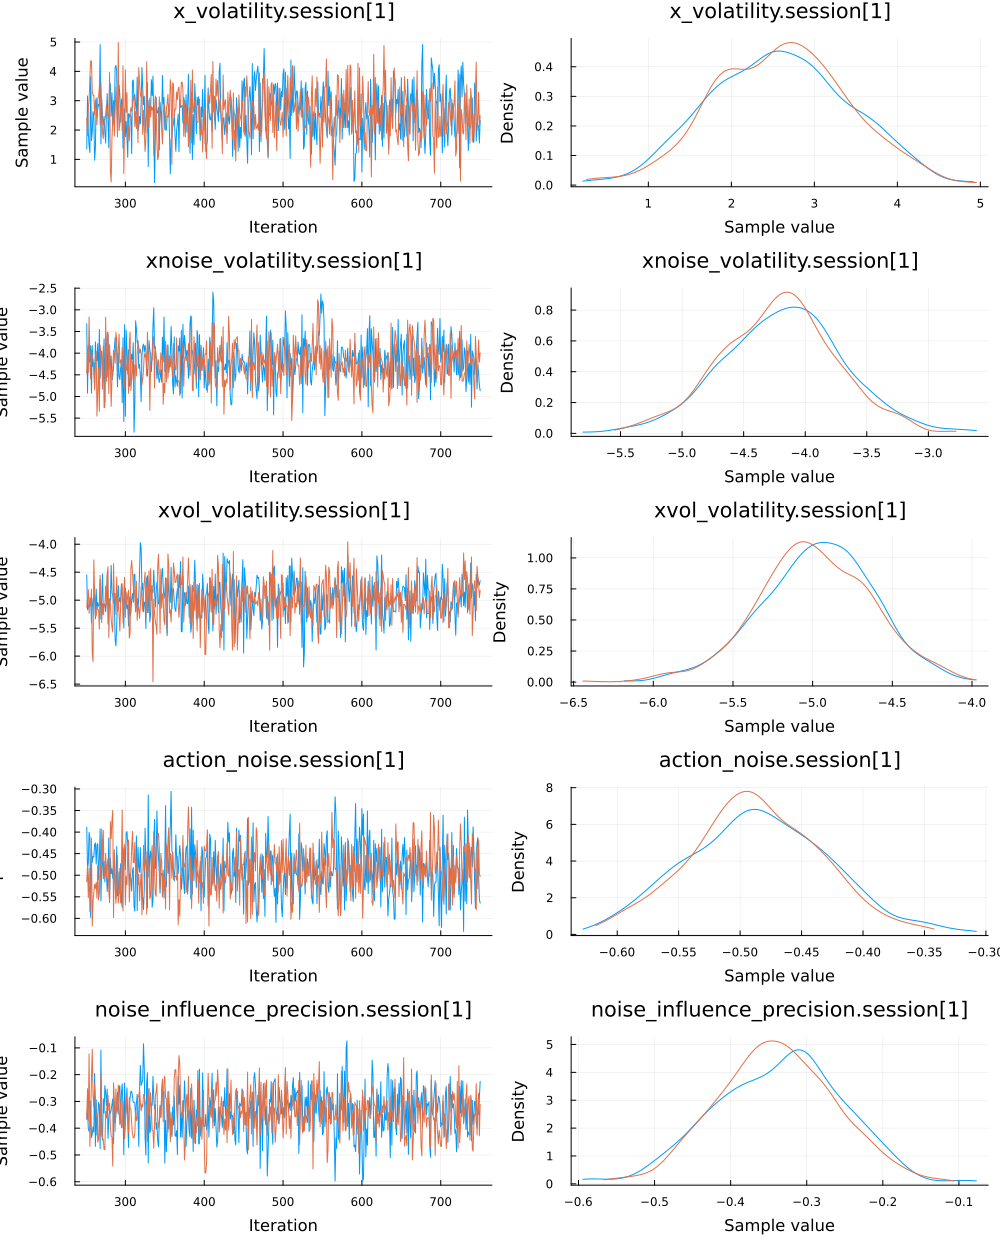

In [44]:
plot(chns)

We can see that there is a negative effect of precision on the action noise.

## Exercise 6
Experiment with the above to find a model that accounts for the data well.
Try and simulate behaviour with the estimated parameter values, and see whether the behaviour is similar to the real behaviour.

# Part 6 (Optional): Multiple participants

In [45]:
#Read into a DataFrame
data = CSV.read(Downloads.download(
  "https://raw.githubusercontent.com/ComputationalPsychiatry/HierarchicalGaussianFiltering.jl/main/docs/julia_files/tutorials/data/classic_cannonball_data.csv"
  ), DataFrame, missingstring = ["NaN", ""])

#Remove ID's with missing responses
data = combine(
    groupby(data, [:ID, :session]),
    subdata -> any(ismissing, Matrix(subdata[!, [:response]])) ? DataFrame() : subdata,
)
disallowmissing!(data, [:response])
#Remove participant 22 from the data, where collection has
data = filter(row -> !(row[:ID] == 22), data)

#z-score the outcome and response
z_μ = mean(vcat(data.outcome, data.response))
z_σ = std(vcat(data.outcome, data.response))
data.outcome_z = (data.outcome .- z_μ) ./ z_σ
data.response_z = (data.response .- z_μ) ./ z_σ

#Filter the data for the first session for the first participant
data = filter(:session => ==(1), data)
data = filter(:ID => in([20, 21, 22, 23, 24]), data)

Row,ID,session,trial,response,outcome,mean,sd,outcome_z,response_z
,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Float64,Float64
1,20,1,1,15,62,61,5,0.282649,-1.7571
2,20,1,2,57,55,61,5,-0.0211435,0.0656544
3,20,1,3,62,52,61,5,-0.15134,0.282649
4,20,1,4,55,50,61,5,-0.238138,-0.0211435
5,20,1,5,49,65,61,5,0.412846,-0.281537
6,20,1,6,61,55,61,5,-0.0211435,0.23925
7,20,1,7,62,43,39,15,-0.541931,0.282649
8,20,1,8,38,59,39,15,0.152452,-0.758926
9,20,1,9,56,32,39,15,-1.01932,0.0222554


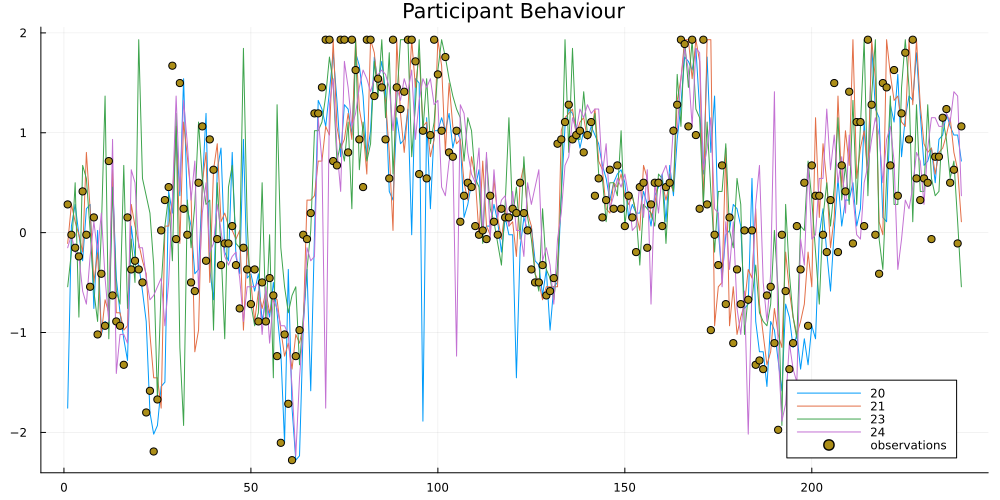

In [46]:
@df data plot(:trial, :response_z, group = :ID, size = (1000,500), title = "Participant Behaviour")

plot!(filter(:ID => ==(20), data).outcome_z, seriestype = :scatter, label = "observations")

In [47]:
#Create a hierarchical population model
population_model = [
    Regression(
      @formula(x_volatility ~ 1 + (1 | ID)),
      identity,
      RegressionPrior( β = [Normal(0, 0.5)], σ = truncated(Normal(0, 0.3), lower = 0))
    ),

    Regression(
      @formula(action_noise ~ 1 + (1 | ID)),
      exp,
      RegressionPrior( β = [Normal(0, 0.5)], σ = truncated(Normal(0, 0.3), lower = 0))
    ),
]

## Adjust the priors based on your simulations and earlier results ##


#Create full model
full_model = create_model(
    action_model,
    population_model,
    data;

    #Specify columns in dataframe
    action_cols = :response_z,
    observation_cols = :outcome_z,
    session_cols = :ID,
    check_parameter_rejections = true,
)

-- ModelFit object --
Action model: hgf_gaussian_response
Linear regression population model
2 estimated action model parameters, 4 sessions
Posterior not sampled
Prior not sampled


In [48]:
chns = sample_posterior!(full_model, MCMCThreads(), n_chains = 2, n_samples = 200)

┌ Warning: Only a single thread available: MCMC chains are not sampled in parallel
└ @ AbstractMCMC /Users/peter/.julia/packages/AbstractMCMC/NK6XN/src/sample.jl:544
Sampling (1 thread)   0%|                               |  ETA: N/A
┌ Info: Found initial step size
│   ϵ = 0.05
└ @ Turing.Inference /Users/peter/.julia/packages/Turing/IXycm/src/mcmc/hmc.jl:207
Sampling (1 thread)   0%|▏                              |  ETA: 0:17:30
Sampling (1 thread)   1%|▎                              |  ETA: 0:08:54
Sampling (1 thread)   2%|▌                              |  ETA: 0:06:16
Sampling (1 thread)   2%|▋                              |  ETA: 0:04:51
Sampling (1 thread)   2%|▊                              |  ETA: 0:04:01
Sampling (1 thread)   3%|▉                              |  ETA: 0:03:43
Sampling (1 thread)   4%|█▏                             |  ETA: 0:03:20
Sampling (1 thread)   4%|█▎                             |  ETA: 0:03:07
Sampling (1 thread)   4%|█▍                             |  ETA

Chains MCMC chain (200×24×2 Array{Float64, 3}):

Iterations        = 101:1:300
Number of chains  = 2
Samples per chain = 200
Wall duration     = 168.47 seconds
Compute duration  = 167.8 seconds
parameters        = x_volatility.β[1], x_volatility.ranef_1.σ[1], x_volatility.ranef_1.r[1], x_volatility.ranef_1.r[2], x_volatility.ranef_1.r[3], x_volatility.ranef_1.r[4], action_noise.β[1], action_noise.ranef_1.σ[1], action_noise.ranef_1.r[1], action_noise.ranef_1.r[2], action_noise.ranef_1.r[3], action_noise.ranef_1.r[4]
internals         = lp, n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size

Summary Statistics
                 parameters      mean       std      mcse   ess_bulk   ess_tai ⋯
                     Symbol   Float64   Float64   Float64    Float64    Float6 ⋯

          x_volatility.β[1]    0.4526    0.4223    0.0213   390.9395   339.517 ⋯
  x_volatil

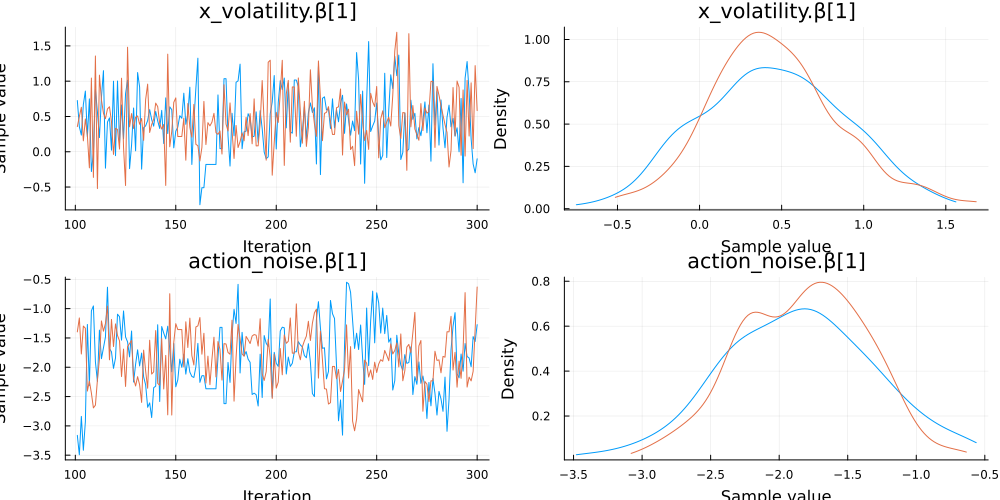

In [49]:
#Plot the group means
plot(chns[["x_volatility.β[1]", "action_noise.β[1]"]])

In [50]:
#Extract individual parameters
session_parameters = get_session_parameters!(full_model)
session_params_df = summarize(session_parameters, median)

Row,ID,action_noise,x_volatility
,String,Float64,Float64
1,20,0.0104476,0.551104
2,21,0.0110956,0.539561
3,23,0.0115334,0.43505
4,24,0.00958495,0.462879


In [51]:
target_state = :x_prediction_mean

#Extract state trajectories
state_trajectories = get_state_trajectories!(full_model, target_state)
state_trajectories_df = summarize(state_trajectories, median)

Row,ID,timestep,x_prediction_mean
,String,Int64,Float64?
1,20,0,0.0
2,20,1,0.273552
3,20,2,0.0969324
4,20,3,-0.0452285
5,20,4,-0.154719
6,20,5,0.16692
7,20,6,0.062392
8,20,7,-0.274129
9,20,8,-0.0416518


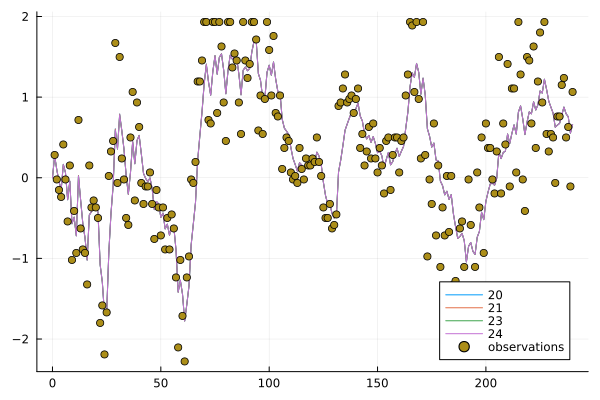

In [52]:
@df state_trajectories_df plot(:timestep, :x_prediction_mean, group = :ID)
plot!(filter(:ID => ==(20), data).outcome_z, seriestype = :scatter, label = "observations")